In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wordcloud import WordCloud, STOPWORDS

In [5]:
%pip install scikit-learn pandas


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pwd
df = pd.read_csv("../sampleddata.csv")
print(df.shape)
df.head()

(25731, 22)


,id,text,epoch,media,retweetedTweet,lang,rawContent,cleanedTweet,replyCount,retweetCount,...,hashtags,mentionedUsers,links,viewCount,quotedTweet,in_reply_to_screen_name,location,user,date,week
0,1.822059e+18,@MTGrepp Hire his own private security.\nWe do...,1.723248e+09,[],False,en,@MTGrepp Hire his own private security.\nWe do...,Hire his own private security.We don’t trust F...,1.0,1.0,...,[],"[{'id_str': '1663701168839872512', 'name': 'Ma...",[],"{'count': '167', 'state': 'EnabledWithCount'}",False,MTGrepp,NaN,"{'id': 1700275343746375680, 'id_str': '1700275...",2024-08-09,14
1,1.822047e+18,"@RpsAgainstTrump @MikePence "" I can't vote for...",1.723245e+09,[],False,en,"@RpsAgainstTrump @MikePence "" I can't vote for...",""" I can't vote for Donald Trump because he tri...",0.0,0.0,...,[],"[{'id_str': '1221462414744596483', 'name': 'Re...",[],"{'count': '11', 'state': 'EnabledWithCount'}",False,RpsAgainstTrump,NaN,"{'id': 1463350602449055748, 'id_str': '1463350...",2024-08-09,14
2,1.822044e+18,From banning fracking to private health insura...,1.723244e+09,[],False,en,From banning fracking to private health insura...,From banning fracking to private health insura...,0.0,0.0,...,[],[],[{'display_url': 'washingtonexaminer.com/opini...,"{'count': '23', 'state': 'EnabledWithCount'}",False,NaN,NaN,"{'id': 1519815039145975809, 'id_str': '1519815...",2024-08-09,14
3,1.822047e+18,Share away.,1.723245e+09,[],False,en,Share away.,Share away.,0.0,0.0,...,[],[],[],"{'count': '45', 'state': 'EnabledWithCount'}",True,NaN,NaN,"{'id': 34396209, 'id_str': '34396209', 'url': ...",2024-08-09,14
4,1.822059e+18,@Arkypatriot FuckALLcensorship,1.723248e+09,[],False,en,@Arkypatriot FuckALLcensorship,FuckALLcensorship,1.0,0.0,...,[],"[{'id_str': '1077019129', 'name': 'USMC Lady V...",[],"{'count': '7', 'state': 'EnabledWithCount'}",False,Arkypatriot,NaN,"{'id': 1546569489491247104, 'id_str': '1546569...",2024-08-09,14


In [7]:
df.describe()

,id,epoch,replyCount,retweetCount,likeCount,quoteCount,week
count,2.573100e+04,2.573100e+04,25731.000000,25731.000000,25731.000000,25731.000000,25731.000000
mean,1.821739e+18,1.723171e+09,46.707163,125.625432,592.970192,7.220940,13.793246
std,2.196072e+16,5.235844e+06,781.186647,1554.005557,9461.016248,105.827581,8.657063
min,1.785460e+18,1.714522e+09,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.803812e+18,1.718897e+09,0.000000,0.000000,0.000000,0.000000,7.000000
50%,1.815038e+18,1.721574e+09,0.000000,0.000000,0.000000,0.000000,11.000000
75%,1.841152e+18,1.727800e+09,0.000000,0.000000,1.000000,0.000000,21.000000
max,1.863010e+18,1.733011e+09,54132.000000,84702.000000,670629.000000,5206.000000,30.000000


In [8]:
df.groupby('week')[['retweetCount','likeCount']].describe()

retweetCount                                                         \
            count         mean          std  min  25%  50%  75%      max   
week                                                                       
0           900.0    25.938889   371.367886  0.0  0.0  0.0  0.0  10424.0   
1          1000.0    43.879000   361.350711  0.0  0.0  0.0  0.0   3835.0   
2           540.0    33.240741   356.318307  0.0  0.0  0.0  0.0   7032.0   
3           740.0    70.682432   520.923735  0.0  0.0  0.0  0.0   8239.0   
4           719.0   109.166898   787.434224  0.0  0.0  0.0  0.0  11241.0   
5           818.0    67.023227   557.564140  0.0  0.0  0.0  0.0  12918.0   
6          1450.0    60.510345  1058.083336  0.0  0.0  0.0  0.0  37906.0   
7           940.0     7.887234   126.544482  0.0  0.0  0.0  0.0   2824.0   
8           645.0   149.275969  1064.686774  0.0  0.0  0.0  0.0  13040.0   
9          1235.0   139.323077  1650.968710  0.0  0.0  0.0  0.0  48517.0   
10         2385.0     1.734591    22.676702  0.0  0.0  0.0  0.0    904.0   
11         1980.0    36.071212   458.863519  0.0  0.0  0.0  0.0  11617.0   
12          420.0   389.347619  1997.031340  0.0  0.0  0.0  0.0  20627.0   
13           80.0     1.125000     5.027456  0.0  0.0  0.0  0.0     39.0   
14         1060.0     2.974528    40.077455  0.0  0.0  0.0  0.0   1082.0   
15         1140.0     5.454386   102.383931  0.0  0.0  0.0  0.0   3346.0   
16          200.0     1.645000    18.754135  0.0  0.0  0.0  0.0    264.0   
17          120.0     4.558333    45.900293  0.0  0.0  0.0  0.0    503.0   
18          184.0   628.907609  5647.543460  0.0  0.0  0.0  0.0  54217.0   
19          426.0    74.164319   693.690262  0.0  0.0  0.0  0.0   9830.0   
20         1169.0    74.256630  1184.072319  0.0  0.0  0.0  0.0  32064.0   
21         1326.0    29.468326   494.713331  0.0  0.0  0.0  0.0  14007.0   
22         1149.0   113.749347  1771.579319  0.0  0.0  0.0  0.0  41246.0   
23         1187.0   221.915754  1381.662374  0.0  0.0  0.0  0.0  14639.0   
24          338.0  1731.127219  5849.229413  0.0  0.0  0.0  0.0  36578.0   
25          460.0  1355.893478  6131.713423  0.0  0.0  0.0  0.0  84702.0   
26          360.0   986.630556  4464.674149  0.0  0.0  0.0  1.0  44991.0   
27          360.0   303.844444  1780.209569  0.0  0.0  0.0  0.0  20209.0   
28          840.0     1.083333    10.224895  0.0  0.0  0.0  0.0    204.0   
29         1020.0     2.551961    26.586837  0.0  0.0  0.0  0.0    605.0   
30          540.0     8.387037   109.616231  0.0  0.0  0.0  0.0   2157.0   

     likeCount                                                           
         count         mean           std  min  25%  50%  75%       max  
week                                                                     
0        900.0   124.153333   1645.083532  0.0  0.0  0.0  2.0   44345.0  
1       1000.0    37.600000    469.583945  0.0  0.0  0.0  2.0   13077.0  
2        540.0   162.016667   1536.748364  0.0  0.0  0.0  1.0   23783.0  
3        740.0   264.656757   1979.036138  0.0  0.0  0.0  1.0   25482.0  
4        719.0   431.378303   3479.973598  0.0  0.0  0.0  1.0   58116.0  
5        818.0   224.716381   2229.846986  0.0  0.0  0.0  1.0   47520.0  
6       1450.0    97.830345   1840.512539  0.0  0.0  0.0  1.0   65507.0  
7        940.0    15.603191    302.177463  0.0  0.0  0.0  1.0    9084.0  
8        645.0   118.376744   1249.819221  0.0  0.0  0.0  1.0   26580.0  
9       1235.0   111.878543   1666.428381  0.0  0.0  0.0  1.0   44972.0  
10      2385.0     8.295178    113.280437  0.0  0.0  0.0  1.0    5049.0  
11      1980.0   168.593939   2113.599136  0.0  0.0  0.0  1.0   47492.0  
12       420.0  1044.923810   6366.850508  0.0  0.0  0.0  1.0   84634.0  
13        80.0     3.812500     16.109667  0.0  0.0  0.0  1.0     130.0  
14      1060.0    15.659434    220.612929  0.0  0.0  0.0  1.0    6223.0  
15      1140.0    17.610526    223.570557  0.0  0.0  0.0  1.0    6501.0  
16       200.0

In [9]:
df['cleanedTweet']

0        Hire his own private security.We don’t trust F...
1        " I can't vote for Donald Trump because he tri...
2        From banning fracking to private health insura...
3                                              Share away.
4                                        FuckALLcensorship
                               ...                        
25726    And what did the Democratic Party do to get yo...
25727    You can’t have two masters ..The Democratic Pa...
25728    Opinion | Former Attorney General Alberto Gonz...
25729    The Green Party is no threat to capitalism or ...
25730    And we enjoyed every minute of it! Kamala Harr...
Name: cleanedTweet, Length: 25731, dtype: str

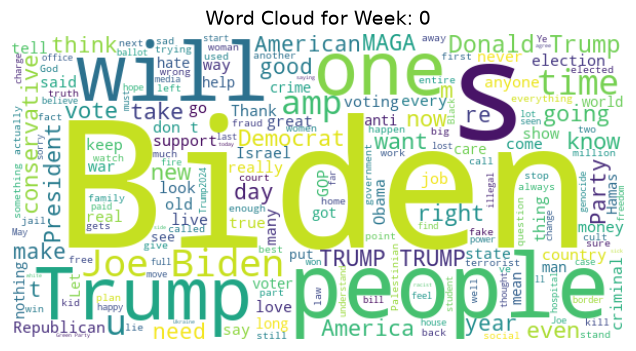

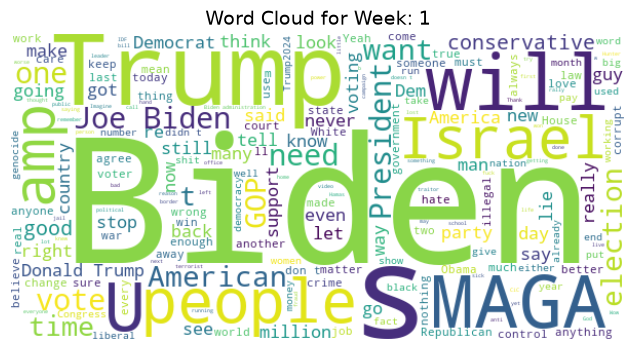

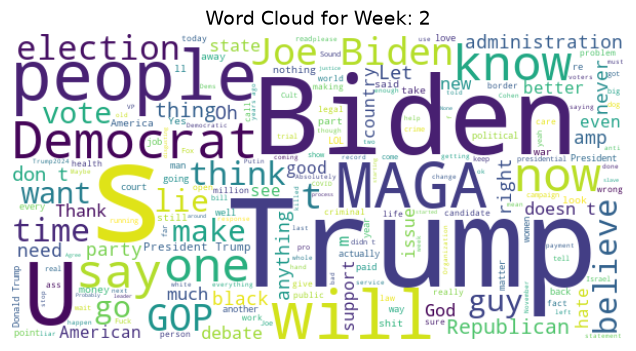

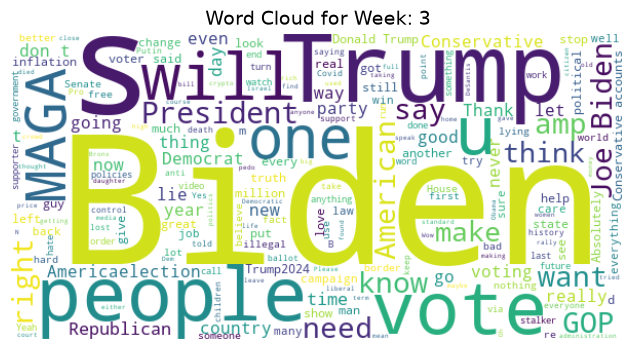

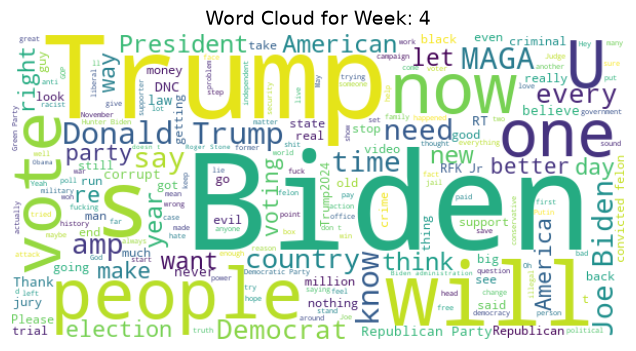

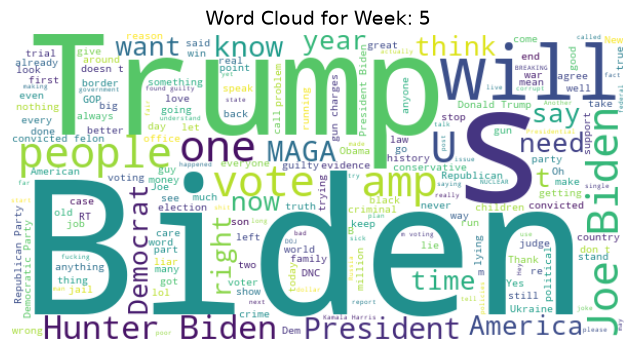

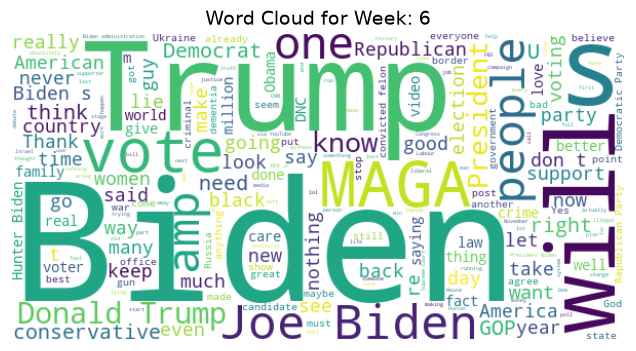

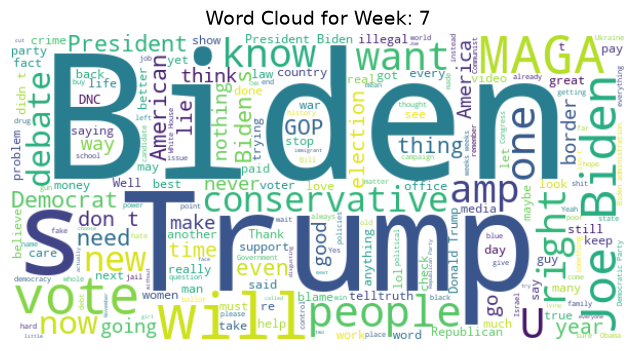

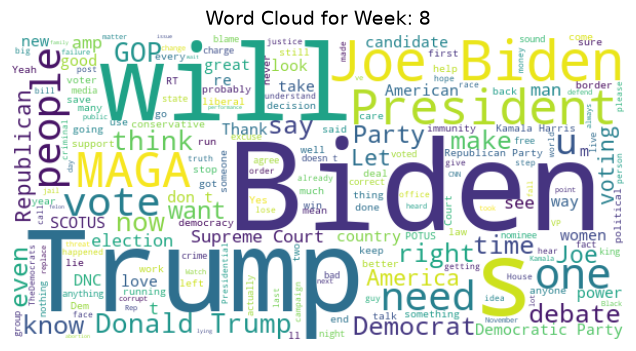

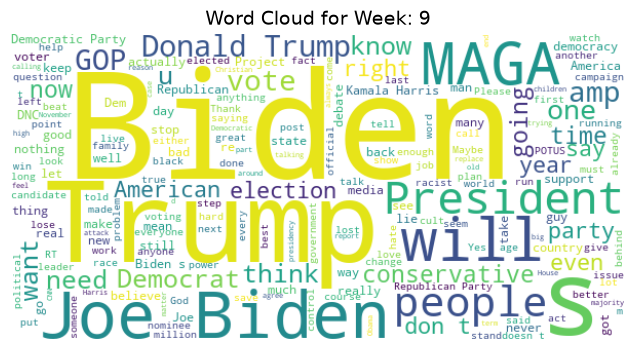

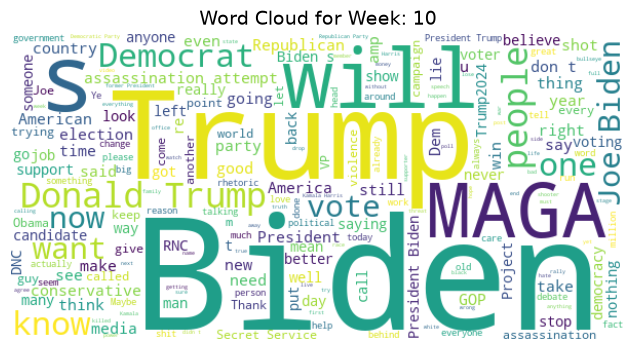

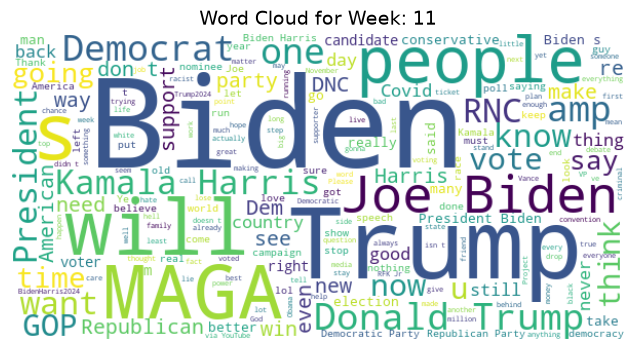

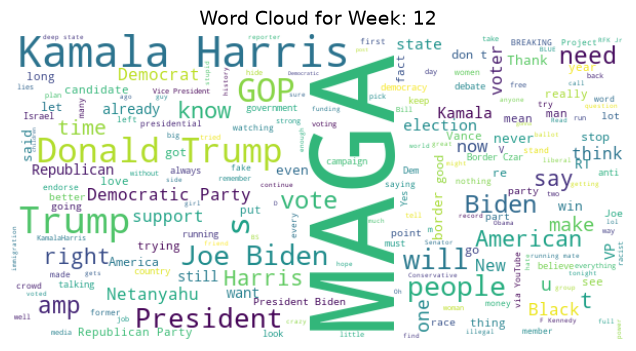

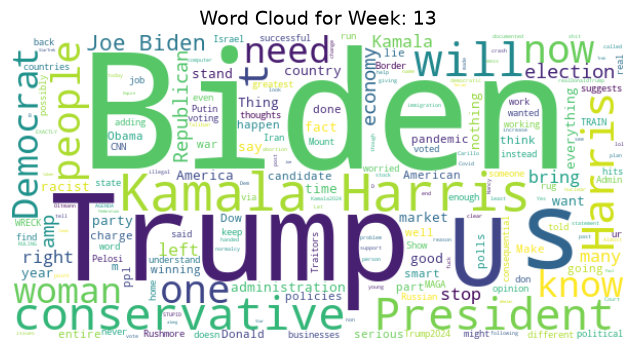

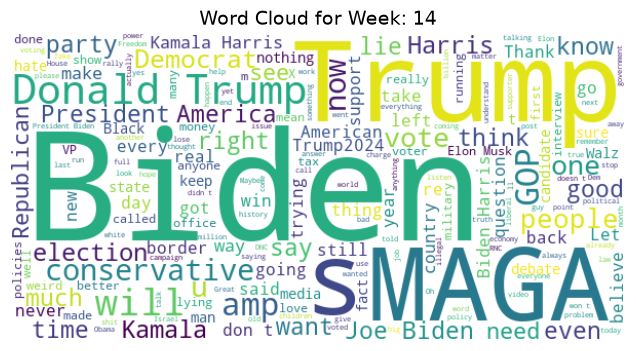

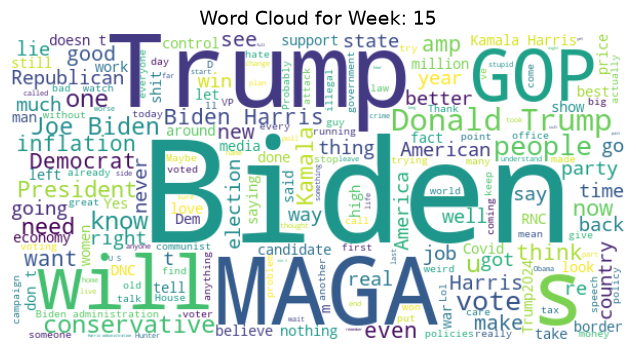

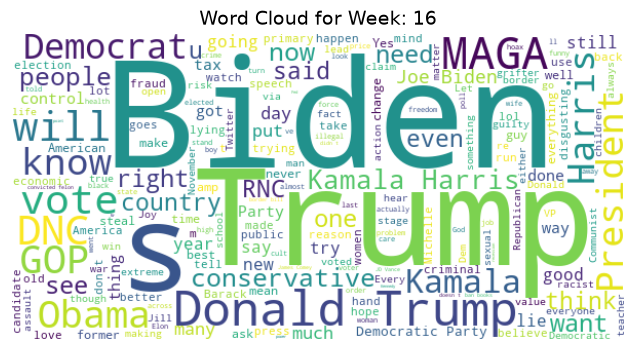

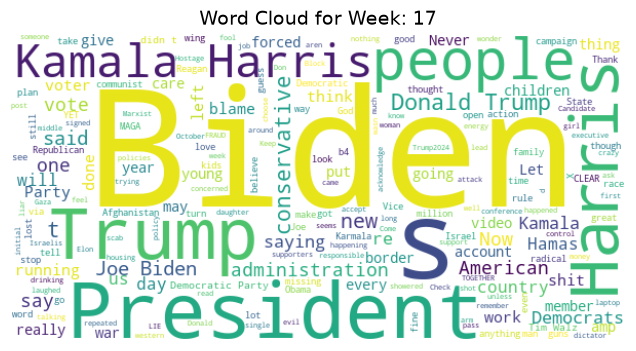

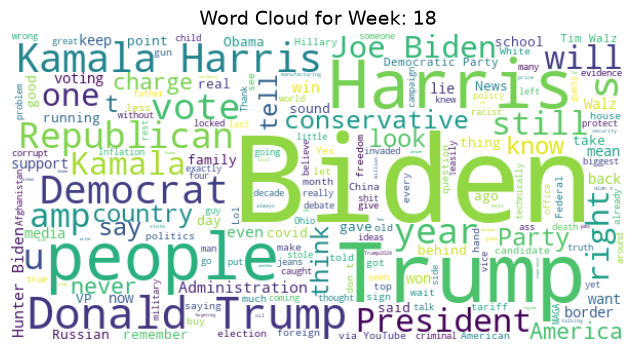

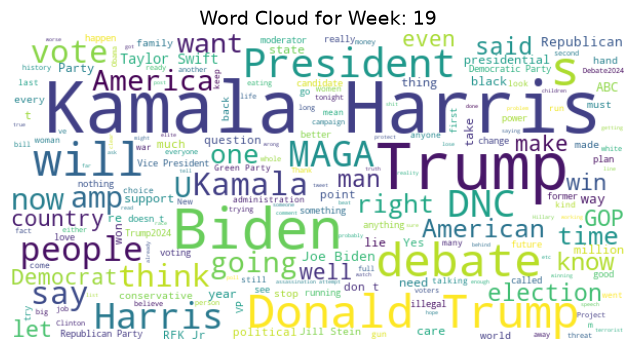

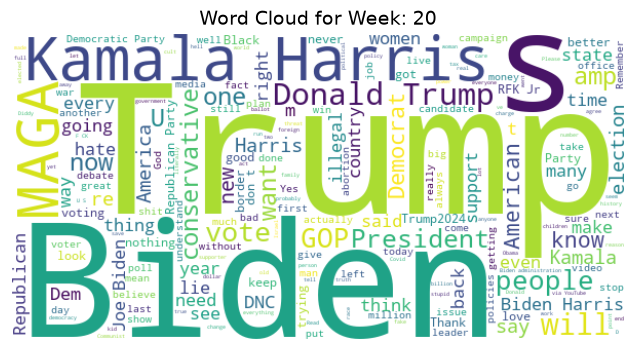

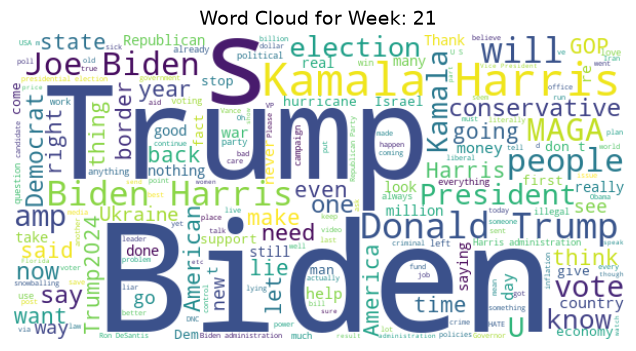

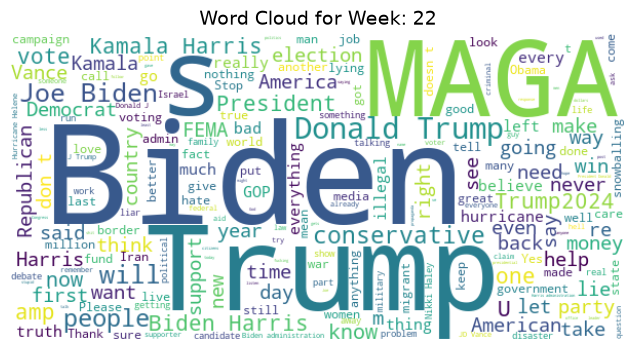

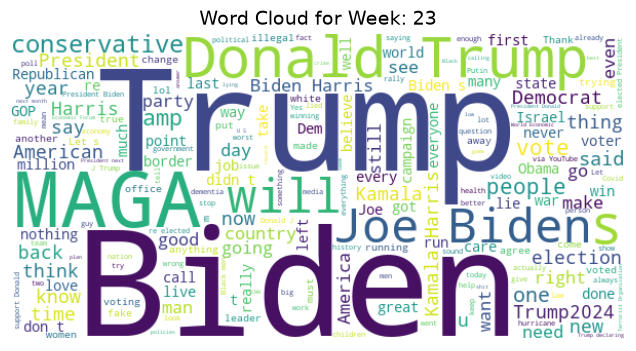

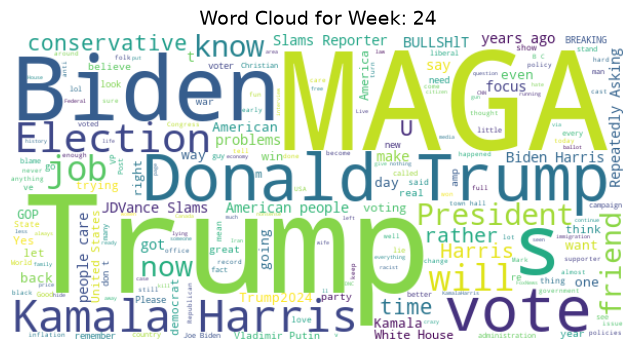

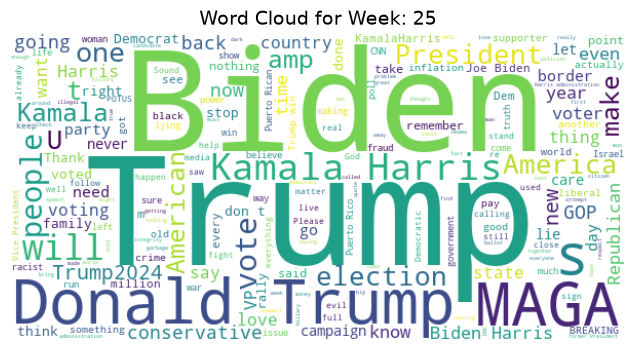

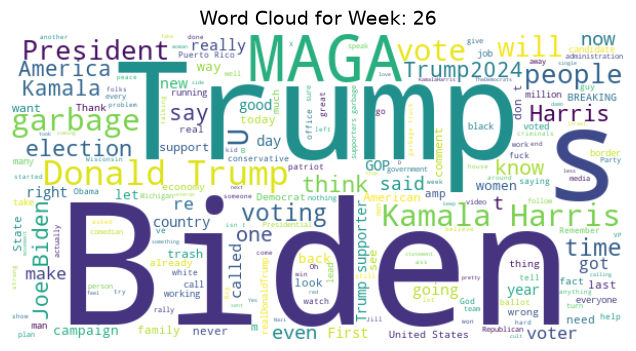

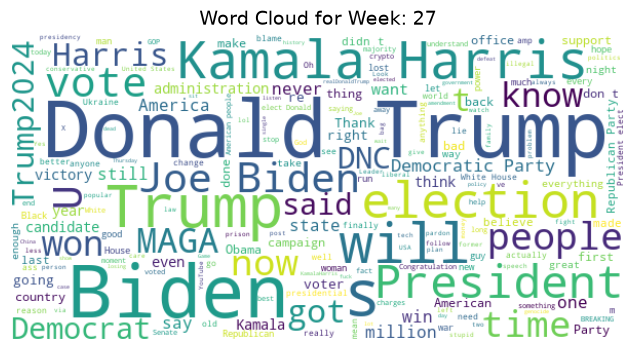

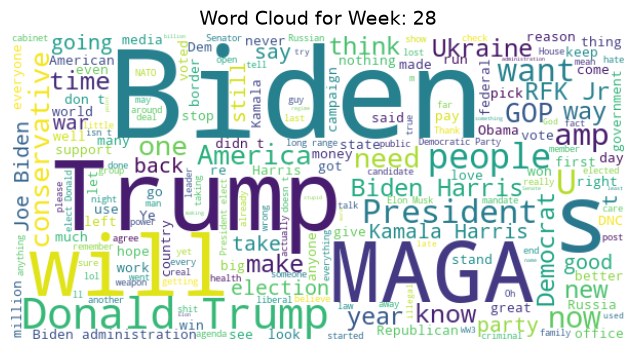

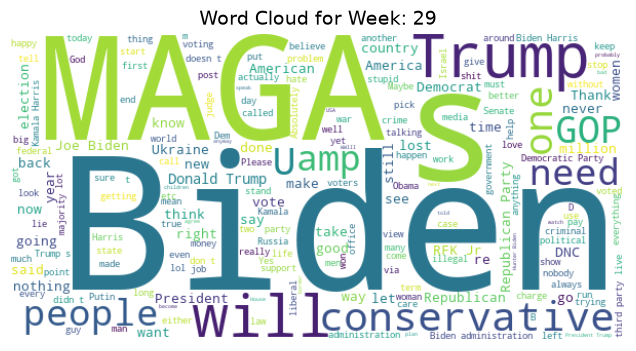

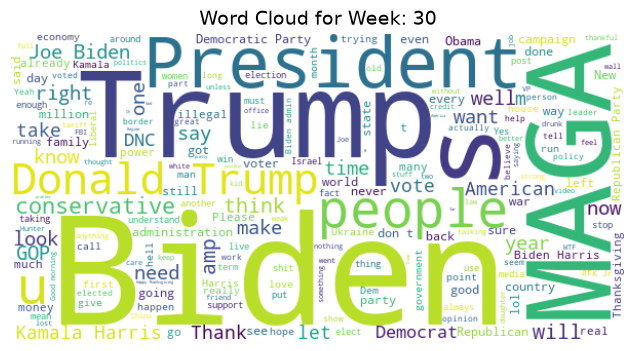

In [10]:
weekly_words = df.groupby('week')['cleanedTweet'].agg(' '.join)
stopwords = set(STOPWORDS)

for index, week in enumerate(weekly_words):
    # Generate the word cloud
    wordcloud = WordCloud(
        width=600,
        height=300,
        background_color='white',
        stopwords=set(STOPWORDS)
    ).generate(week)

    # Display the word cloud labeled by the week ending date
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for Week: {index}", fontsize=14)
    plt.axis('off')
    plt.show()

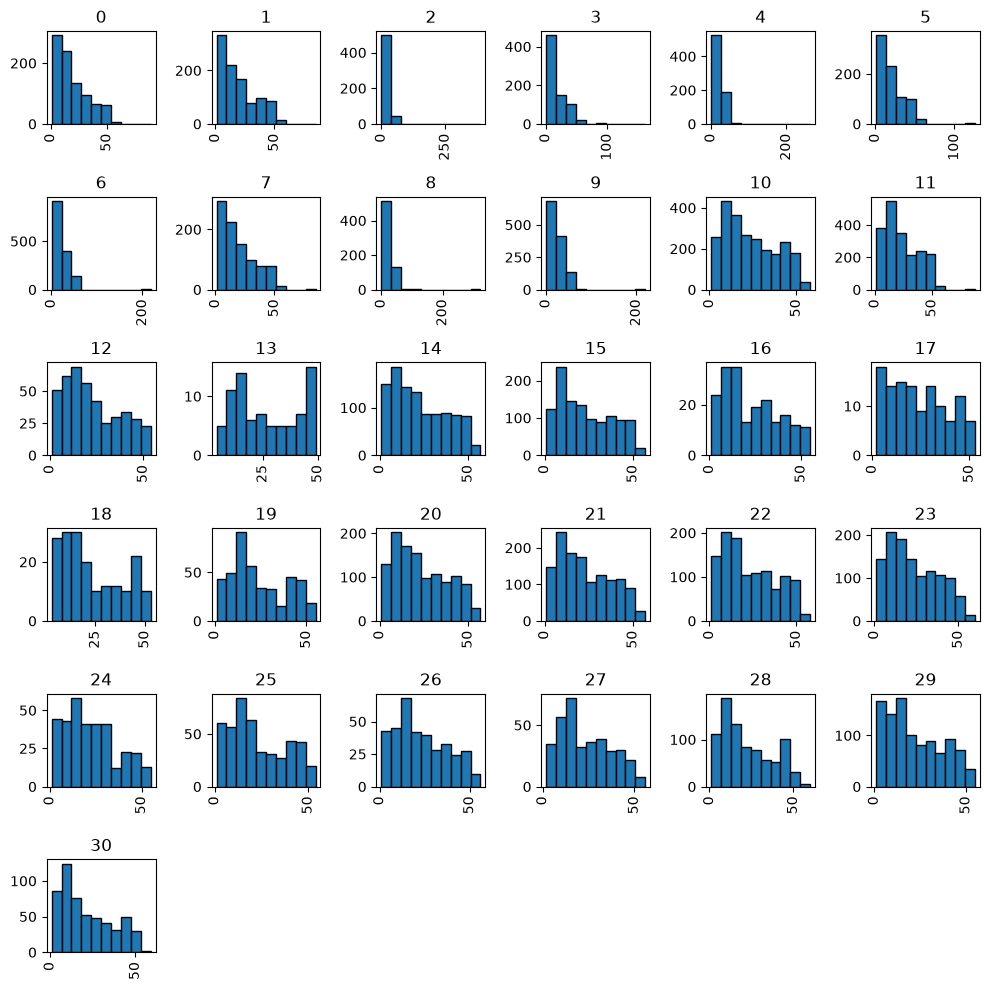

In [11]:
df['tweet_length'] = df['cleanedTweet'].str.split().str.len()
grouped = df.groupby('week')

df.hist(column='tweet_length', by='week', edgecolor='black',figsize=(10,10))
plt.tight_layout()
plt.show()

In [12]:
df.groupby('week')['tweet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,900.0,19.004444,14.355179,1.0,8.00,15.0,28.00,89.0
1,1000.0,19.559000,14.556112,1.0,8.00,15.0,29.00,85.0
2,540.0,16.840741,24.312220,1.0,6.00,11.0,21.00,388.0
3,740.0,18.214865,15.879913,1.0,7.00,12.5,26.25,162.0
4,719.0,20.112656,18.798813,1.0,8.00,15.0,28.50,263.0
5,818.0,19.738386,15.022953,1.0,8.00,16.0,28.00,126.0
6,1450.0,20.806207,16.603411,1.0,8.00,16.0,32.00,218.0
7,940.0,19.486170,14.223262,1.0,8.00,15.0,29.00,85.0
8,645.0,19.793798,19.559178,1.0,7.00,15.0,28.00,323.0


# Topic Modeling: LDA & NMF
**Author:** TK Garrett


This portion of the notebook used unsupervised topic modeling (LDA and NMF) on the cleaned
tweets to identify the main discussion themes and track how they shift week
to week during the campaign.

In [13]:
#Uses Jesse's cleanedTweet column to drop missing values. 
docs=df["cleanedTweet"].dropna().astype(str)
#Creating a new dataframe with only tweets that have 5 or more words for meaningful for analysis.
docs=docs[docs.str.split().str.len() >= 5]
print(len(docs), "tweets used for topic modeling")
docs.head(10)

23563 tweets used for topic modeling


0     Hire his own private security.We don’t trust F...
1     " I can't vote for Donald Trump because he tri...
2     From banning fracking to private health insura...
5     maybe he’s just used to looking up and not dow...
6     We all know it’s not you Joe Biden running thi...
8     I got the most bills passed of GOP and second ...
9                Your words are words only MAGA speaks.
10    Your showing a segment about nuclear weapons l...
11    Dem policies:🍔Free school lunch👶Universal pre-...
12    But what would she do? Can you provide a link ...
Name: cleanedTweet, dtype: str

In [14]:
#Fit LDA and NMF models to the cleaned tweets. This will help identify underlying topics in the tweets.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Number of topics for topic modeling. This can be adjusted based on the desired granularity of topics.
N_TOPICS = 5

# LDA (Latent Dirichlet Allocation)
# max_df=0.95 ignores words that appear in more than 95% of tweets;
# min_df=5 ignores words that appear in fewer than 5 tweets
count_vec = CountVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_counts = count_vec.fit_transform(docs)
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42)
lda.fit(X_counts)

#NMF (Non-negative Matrix Factorization)
tfidf_vec = TfidfVectorizer(stop_words="english", max_df=0.95, min_df=5)
X_tfidf = tfidf_vec.fit_transform(docs)
nmf = NMF(n_components=N_TOPICS, init="nndsvd", random_state=42)
nmf.fit(X_tfidf)

# random_state=42 makes results repeatable, so everyone gets the same topics




,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",'nndsvd'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary <random_state>`.",42
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [15]:
#TOPICS
# Prints the top words for each topic so we can interpret what each one is about
def show_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        #Sorts words by how strongly they belong to this topic and keep the top n
        top = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        print(f"Topic {i}: {', '.join(top)}")

# Compare the two models: which gives clearer, less overlapping topics?
print("--- LDA---")
show_topics(lda, count_vec)
print("\n--- NMF ---")
show_topics(nmf, tfidf_vec)

--- LDA---
Topic 0: trump, biden, donald, time, maga, like, just, jr, love, did
Topic 1: maga, biden, trump, vote, just, people, amp, don, like, conservative
Topic 2: biden, harris, kamala, joe, president, trump, administration, border, election, did
Topic 3: trump, donald, like, biden, conservative, president, people, don, want, american
Topic 4: biden, party, trump, republican, gop, like, democratic, people, just, obama

--- NMF ---
Topic 0: biden, joe, president, did, administration, said, years, hunter, didn, obama
Topic 1: trump, donald, president, america, election, 2024, support, assassination, youtube, elon
Topic 2: maga, america, cult, let, make, trump2024, love, trump, great, maha
Topic 3: harris, kamala, president, vp, vice, youtube, debate, border, campaign, voting
Topic 4: party, like, people, just, don, vote, conservative, gop, republican, know


<Axes: title={'center': 'NMF topic share by week'}, xlabel='week'>

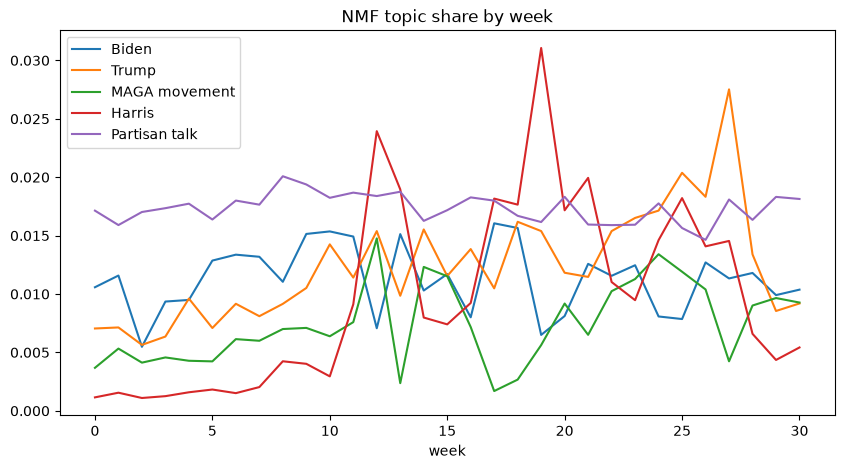

In [16]:
#Topics Over Time
# How much each of the NMF topics shows up in each week of the campaign;
# rising/falling lines show which narratives gained or lost attention
doc_topics = nmf.transform(X_tfidf)              
topic_df = pd.DataFrame(doc_topics, index=docs.index)
topic_df["week"] = df.loc[docs.index, "week"]    

weekly_topics = topic_df.groupby("week").mean()
weekly_topics.columns = [
    "Biden",
    "Trump",
    "MAGA movement",
    "Harris",
    "Partisan talk",
]
weekly_topics.plot(figsize=(10, 5), title="NMF topic share by week")